In [49]:
import numpy as np
import matplotlib.pyplot as plt
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image

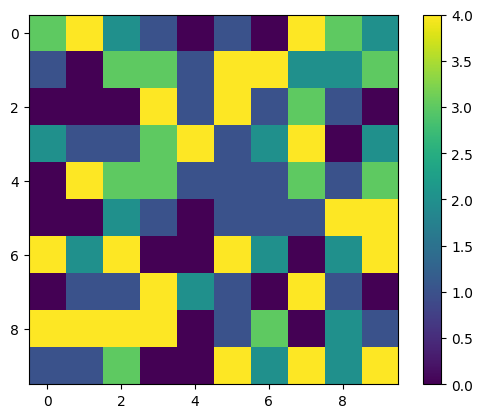

In [24]:
grid_size = 50

grid = np.random.choice((0,1,2,3,4),(N,N))

plt.imshow(grid)
plt.colorbar()

In [10]:
def lavine(grid):
    mask = np.where(grid >= 4)

In [17]:
mask = np.where(grid >= 4)
mask = grid >= 4

In [35]:
def topple_once(grid, mask):
    """
    One non-periodic redistribution step:
    cells with value >= 4 lose 4 and give +1 to N,S,E,W neighbours.
    Grains leaving the boundary are deleted.
    """
    grid = np.asarray(grid)
    m = mask.astype(grid.dtype)
    touples = np.sum(m)
    out = grid.copy()

    # Each toppled site loses 4
    out -= 4 * m
    
    # Each neighbour receives +1 from adjacent toppled cells
    out[:-1,  :] += m[1:,  :]   # from below (south) toppled cells
    out[1:,   :] += m[:-1, :]   # from above (north) toppled cells
    out[:,  :-1] += m[:, 1: ]   # from right (east) toppled cells
    out[:,   1:] += m[:, :-1]   # from left (west) toppled cells

    mask = out >= 4
    return out, mask, touples


In [100]:
def SOC(n, N):
    sandbox_hist = np.zeros((n,N,N))
    #sandbox = np.random.choice((0,1,2,3),(N,N))
    sandbox = np.zeros((N,N))
    count = np.zeros(n)
    grid_height = np.zeros(n)
    for _ in range(n):
        i,j = np.random.randint(0,N, size = 2)
        sandbox[i,j] += 1
        mask = sandbox >= 4
        while mask.any():
            sandbox, mask, touples = topple_once(sandbox, mask)
            count[_] += touples

        grid_height[_] = np.mean(sandbox)
        sandbox_hist[_] = sandbox
    return sandbox_hist, count, grid_height

def save_grid_gif(gridlist, filename="sandpile.gif", step=100, cmap="viridis"):
    """
    Save a GIF from gridlist of shape (n, N, N).
    Uses every `step` frame.
    """
    frames = []
    for i in range(0, gridlist.shape[0], step):
        fig, ax = plt.subplots(figsize=(4, 4))
        im = ax.imshow(gridlist[i], cmap=cmap, vmin=0, vmax=gridlist.max())
        ax.set_title(f"Frame {i}")
        ax.axis("off")

        # render canvas to image
        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(Image.fromarray(img))

        plt.close(fig)

    # save as GIF
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=200,  # ms per frame
        loop=0
    )
        

In [94]:
grids, counts, grid_height = SOC(100000,50)


In [101]:
grids2, counts2, grid_height2 = SOC(10000,50)


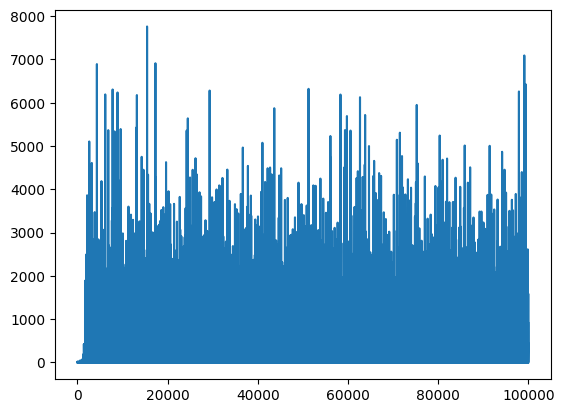

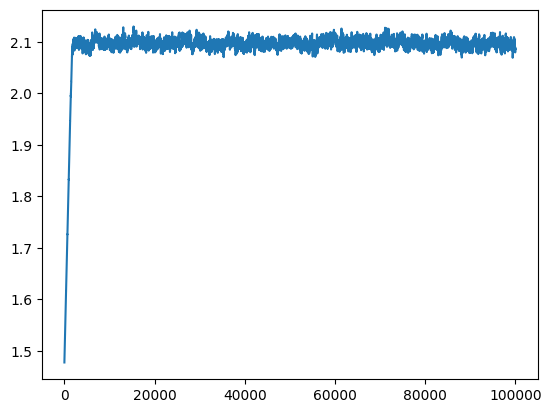

In [95]:
plt.plot(counts)

plt.show()
plt.plot(grid_height)

plt.show()

In [ ]:
np.histogram()

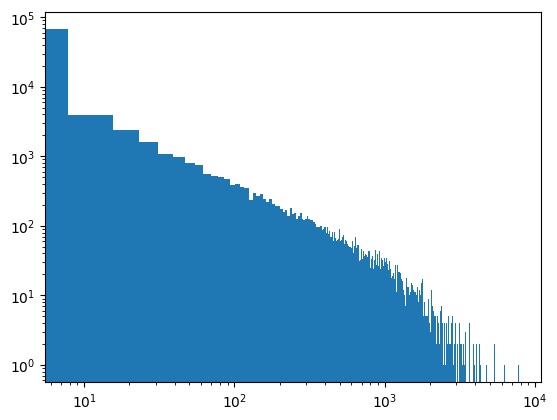

In [119]:
Hist = plt.hist(counts[5000:], bins=1000)
y0 = Hist[0]
x0 = Hist[1]
plt.xscale("log")
plt.yscale("log")


In [102]:
save_grid_gif(grids2, filename="sandpile2.gif", step=100, cmap="viridis")

C:\Users\lucq0\AppData\Local\Temp\ipykernel_1800\602615982.py:33: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)


In [120]:
x0 = x0[1:]

Fit: y ≈ 1683124.506 * x^(-1.664)


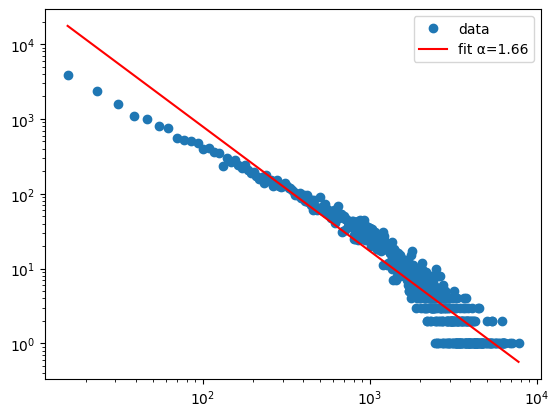

In [129]:
x = x0[1:]
y = y0[1:]
mask = (y > 0) & (x > 0)
x = x[mask]
y = y[mask]

logx = np.log(x)
logy = np.log(y)

# linear regression in log-log space
coeffs = np.polyfit(logx, logy, 1)
slope, intercept = coeffs   # slope = -alpha, intercept = log(a)

alpha = -slope
a = np.exp(intercept)
print(f"Fit: y ≈ {a:.3f} * x^(-{alpha:.3f})")

plt.loglog(x, y, 'o', label="data")
plt.loglog(x, a * x**(-alpha), 'r-', label=f"fit α={alpha:.2f}")
plt.legend()
plt.show()


Initial min: 0.0025751511148494055


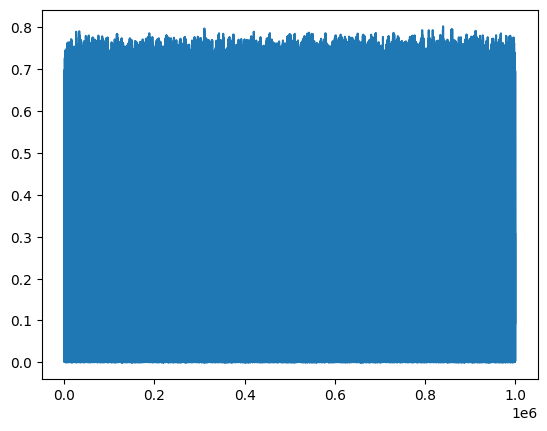

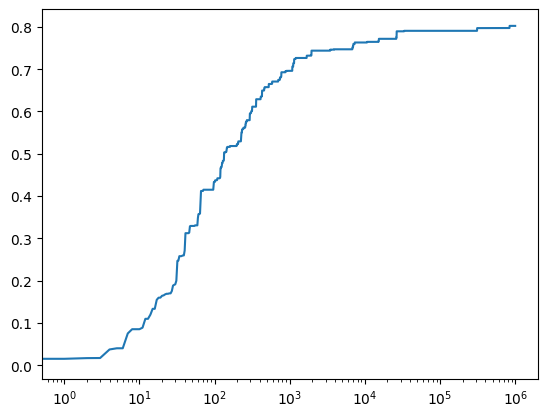

In [144]:
import numpy as np

# initial list
arr = np.random.uniform(size=100)
print("Initial min:", arr.min())

n = 1000000  # number of updates
min_history = []

for _ in range(n):
    # index of current minimum
    i = np.argmin(arr)

    # pick neighbour (handle boundaries)
    if i == 0:
        j = 1
    elif i == len(arr) - 1:
        j = len(arr) - 2
    else:
        j = i + np.random.choice([-1, 1])

    # update both values with new random numbers
    arr[i] = np.random.uniform()
    arr[j] = np.random.uniform()

    # record new minimum
    min_history.append(arr.min())

# results
min_history = np.array(min_history)
#print("Minimum values recorded:", min_history)
#print("Maximum of recorded minima:", min_history.max())
max_values = np.zeros(n)
max_values[0] = min_history[0]

for i in range(1, n):
    max_values[i] = max(max_values[i-1], min_history[i])
plt.plot(min_history)
plt.show()
plt.plot(max_values)
plt.xscale("log")
#plt.yscale("log")
